In [1]:
from sklearn.metrics import log_loss, roc_auc_score
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from __future__ import annotations
from pathlib import Path
from typing import Union
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
'''dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]
match_df = dfs[np.random.randint(len(dfs))]'''

'dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]\nmatch_df = dfs[np.random.randint(len(dfs))]'

In [3]:
data = pd.read_parquet("data/processed/data_processed.parquet")

In [4]:
rand_id = (data['match_id'].unique())[np.random.randint(len(data['match_id'].unique()))]
#rand_id = '2023-usopen-1131'
match_df = data[data['match_id'] == rand_id]
(match_df)

,match_id,SetNo,GameNo,PointNumber,point_idx,time,elapsed_time,perspective,server_is_persp,pts_in_game_for,...,opp_fs_win_pct,opp_ss_win_pct,opp_ret_win_pct,opp_aces,opp_double_faults,opp_df_rate,opp_ace_rate,opp_bp_conv_rate,opp_bp_defend_rate,y_match
730122,2014-ausopen-1312,1,1,1,1,0.0,0.0,False,True,0,...,0.0,0.0,0.000000,0,0,0.000000,0.000000,0.0,0.0,False
730123,2014-ausopen-1312,1,1,2,2,0.0,0.0,False,True,1,...,0.0,0.0,0.000000,0,0,0.000000,0.000000,0.0,0.0,False
730124,2014-ausopen-1312,1,1,3,3,0.0,0.0,False,True,1,...,0.0,0.0,0.500000,0,0,0.000000,0.000000,0.0,0.0,False
730125,2014-ausopen-1312,1,1,4,4,0.0,0.0,False,True,2,...,0.0,0.0,0.333333,0,0,0.000000,0.000000,0.0,0.0,False
730126,2014-ausopen-1312,1,1,5,5,0.0,0.0,False,True,3,...,0.0,0.0,0.250000,0,0,0.000000,0.000000,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730513,2014-ausopen-1312,3,8,194,194,0.0,0.0,True,False,0,...,0.0,0.0,0.298851,8,8,0.075472,0.075472,0.0,0.0,True
730514,2014-ausopen-1312,3,8,195,195,0.0,0.0,True,False,1,...,0.0,0.0,0.298851,8,8,0.074766,0.074766,0.0,0.0,True
730515,2014-ausopen-1312,3,8,196,196,0.0,0.0,True,False,2,...,0.0,0.0,0.298851,8,8,0.074074,0.074074,0.0,0.0,True
730516,2014-ausopen-1312,3,8,197,197,0.0,0.0,True,False,3,...,0.0,0.0,0.298851,8,8,0.073394,0.073394,0.0,0.0,True


In [5]:
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

print_full(match_df)

                 match_id  SetNo  GameNo  PointNumber  point_idx  time  \
730122  2014-ausopen-1312      1       1            1          1   0.0   
730123  2014-ausopen-1312      1       1            2          2   0.0   
730124  2014-ausopen-1312      1       1            3          3   0.0   
730125  2014-ausopen-1312      1       1            4          4   0.0   
730126  2014-ausopen-1312      1       1            5          5   0.0   
730127  2014-ausopen-1312      1       2            6          6   0.0   
730128  2014-ausopen-1312      1       2            7          7   0.0   
730129  2014-ausopen-1312      1       2            8          8   0.0   
730130  2014-ausopen-1312      1       2            9          9   0.0   
730131  2014-ausopen-1312      1       2           10         10   0.0   
730132  2014-ausopen-1312      1       3           11         11   0.0   
730133  2014-ausopen-1312      1       3           12         12   0.0   
730134  2014-ausopen-1312      1      

In [6]:
match_df.to_csv("test.csv")

In [7]:
def predict_win_probability(match_df, rand_id, model, feature_cols, names):
    X_test,  y_test  = match_df[feature_cols],  match_df['y_match']
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    print("Log Loss:", log_loss(y_test, y_pred_prob))
    print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

    win_prob = []
    for _,point in match_df.iterrows():
        X_point = point[feature_cols].values.reshape(1, -1)
        prob = model.predict_proba(X_point)[0, 1]  # probability Player 1 wins match
        win_prob.append(prob)

    plt.plot(win_prob[:len(win_prob)//2], label='Win Probability (Player 1)')
    plt.xlabel('Point Index')
    plt.ylabel('Probability Player Wins Match')

    plt.plot(win_prob[len(win_prob)//2:], label='Win Probability (Player 2)')
    plt.title(f'Live Win Probability Prediction (Match ID: {rand_id}, Model: {names})')
    plt.ylim(0, 1)
    plt.legend()
    ax = plt.gca()
     #draw_set_boundary_markers(ax, match_df)  # adds '--' for P1 and ':' for P2

    plt.show()



Log Loss: 0.18923606058283726
ROC AUC: 0.9998214467911437


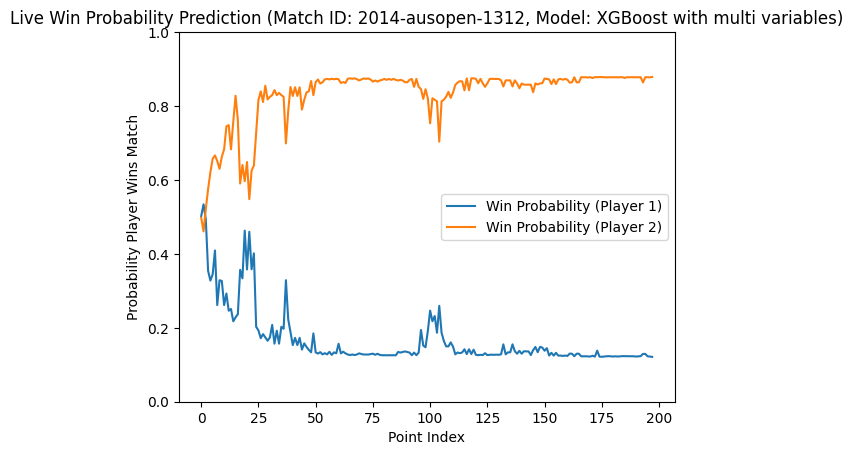

In [8]:
model_df = pd.read_parquet("model_data.parquet", engine="pyarrow")
for i in range(len(model_df)):
    model = XGBClassifier()
    model.load_model('models/xgb_model_1.json')
    feature_cols = model_df['input_columns'][i].split('$')
    predict_win_probability(match_df, rand_id, model, feature_cols, model_df['model_desc'][i])

In [9]:
for i in match_df.columns:
    print((match_df[i]).head(1)) 


730122    2014-ausopen-1312
Name: match_id, dtype: object
730122    1
Name: SetNo, dtype: Int64
730122    1
Name: GameNo, dtype: Int64
730122    1
Name: PointNumber, dtype: int16
730122    1
Name: point_idx, dtype: int64
730122    0.0
Name: time, dtype: float64
730122    0.0
Name: elapsed_time, dtype: float64
730122    False
Name: perspective, dtype: bool
730122    True
Name: server_is_persp, dtype: bool
730122    0
Name: pts_in_game_for, dtype: int64
730122    0
Name: pts_in_game_against, dtype: int64
730122    0
Name: games_in_set_for, dtype: int64
730122    0
Name: games_in_set_against, dtype: int64
730122    0
Name: sets_for, dtype: int64
730122    0
Name: sets_against, dtype: int64
730122    5
Name: best_of, dtype: int64
730122    3
Name: sets_needed_to_win, dtype: int64
730122    False
Name: is_tiebreak, dtype: bool
730122    False
Name: is_game_point_for, dtype: bool
730122    False
Name: is_game_point_against, dtype: bool
730122    False
Name: is_break_point, dtype: bool
730122